# Survival Analysis: When Do Users Churn?

Notebooks 01–07 treat churn as a binary label — inactive for 14 days after one snapshot. That answers *who* is at risk, but not *when* risk strikes, which is the question an intervention calendar actually needs: when should onboarding nudges fire, and how do risk profiles differ over time? This notebook reframes churn as **time-to-event**: Kaplan-Meier curves, log-rank tests, and a Cox proportional-hazards model on the signup cohort.

**Churn (event):** the first sustained inactivity gap — 14 consecutive days with no listening event, consistent with the project's 14-day churn concept — dated when the silence completes (last active day + 14). Users without such a gap are right-censored at the data horizon. Reactivations after a qualifying silence are ignored: first sustained disengagement is the event.

**Cohort and left truncation:** users who signed up on/after the event log's first day (9,759 users), so every user's full history is observed and duration runs from signup with no left truncation. Pre-log signups are *excluded* rather than entered mid-history — their unobserved early behavior would silently bias both the curves and the covariates.

**Leakage-safe covariates by construction:** all behavioral covariates are landmarked to week 1 (days 0–6 after signup), and the earliest possible event time is day 14 — so every covariate is fully determined before any event can occur.

**Dependencies:** `sql/build_survival_table.sql` (rebuildable via `scripts/build_survival_table.py`); lifelines wrappers in `src/survival_analysis.py` (unit-tested in `tests/`, including the SQL's duration/event construction on a synthetic event log).

## 1. Data Loading and QA

In [1]:
# Environment setup. Data is auto-discovered by src/data_loader.py
# (./data in the repo, /content/data on Colab, or STREAMING_DATA_DIR).
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from src.config import RANDOM_SEED
from src.data_loader import connect
from src.survival_analysis import (
    build_cox_design,
    check_proportional_hazards,
    concordance_on_holdout,
    fit_cox,
    fit_km,
    hazard_ratio_table,
    km_by_segment,
    logrank_by_segment,
    median_survival_summary,
    qa_check_survival_table,
)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

SEGMENT_COLORS = ["#1f77b4", "#ff7f0e", "#9467bd", "#17becf"]
NEUTRAL_COLOR = "#7f7f7f"

conn, sql, run_script = connect()
run_script((REPO_ROOT / "sql" / "build_survival_table.sql").read_text())
survival = sql("SELECT * FROM survival_table")
qa_check_survival_table(survival)

print(f"Cohort: {len(survival):,} users | events: {survival['churn_event'].mean():.1%} "
      f"| censored: {1 - survival['churn_event'].mean():.1%}")
print(f"Duration range: {survival['duration_days'].min():.0f}-"
      f"{survival['duration_days'].max():.0f} days")
survival.head()

Loaded tables: users, listening_events, subscription_events, ad_events, feature_table


Cohort: 9,759 users | events: 71.0% | censored: 29.0%
Duration range: 14-103 days


,user_id,signup_date,acquisition_channel,device,age_group,music_persona,active_days_w1,listen_events_w1,skip_rate_w1,playlist_or_like_w1,duration_days,churn_event
0,U000001,2026-02-06,organic_search,mobile_android,35-44,commute_listener,0,0,0.0,0,14.0,1
1,U000002,2026-03-07,paid_social,mobile_android,25-34,playlist_builder,1,1,0.0,0,37.0,1
2,U000006,2026-03-09,email_campaign,mobile_android,25-34,commute_listener,2,2,0.0,0,17.0,1
3,U000008,2026-01-19,app_store,desktop,25-34,social_listener,1,1,0.0,0,17.0,1
4,U000009,2026-03-06,paid_social,mobile_ios,18-24,playlist_builder,4,4,0.0,0,39.0,0


## 2. Reconciliation with the Binary 14-Day Label

Three churn numbers now exist and they must not be confused. The cell below puts them side by side for the same cohort.

In [2]:
cohort_labels = survival.merge(
    sql("SELECT user_id, churn_label_14d FROM feature_table"), on="user_id"
)
binary_rate = cohort_labels["churn_label_14d"].mean()
event_share = survival["churn_event"].mean()
print(f"Project-wide binary 14d churn (notebooks 01-05):        47.6%")
print(f"This cohort's binary 14d churn at the snapshot:         {binary_rate:.1%}")
print(f"This cohort's survival event share (ever disengaged):   {event_share:.1%}")

Project-wide binary 14d churn (notebooks 01-05):        47.6%
This cohort's binary 14d churn at the snapshot:         49.3%
This cohort's survival event share (ever disengaged):   71.0%


The three numbers answer three different questions:

- **47.6%** is a *stock* measure over all 50K users: who is inactive in one specific 14-day window after the snapshot.
- **49.3%** is the same stock measure restricted to this signup cohort — slightly higher because young accounts churn more (notebook 04's cohort finding).
- **71.0%** is a *flow* measure: the share of the cohort that has **ever** completed a 14-day silence at any point in up to 103 days of follow-up. It is necessarily larger — it accumulates every disengagement since signup, including users who later reactivated (the binary snapshot counts those as active) — and the remaining 29% are censored, not survivors forever.

The survival lens does not contradict the label; it unpacks it over time.

## 3. Overall Survival Curve

Median time to churn: 35 days (95% CI [33, 35])
Still engaged at day {14: '79.6%', 30: '54.4%', 60: '33.3%', 90: '22.4%'}


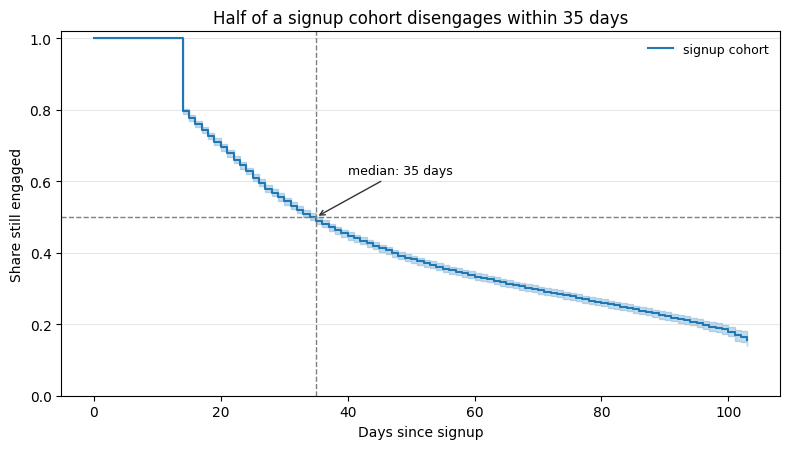

In [3]:
km_all = fit_km(survival, label="signup cohort")
med = median_survival_summary(km_all)
milestones = {t: float(km_all.predict(t)) for t in (14, 30, 60, 90)}
print(f"Median time to churn: {med['median']:.0f} days "
      f"(95% CI [{med['ci_low']:.0f}, {med['ci_high']:.0f}])")
print("Still engaged at day", {t: f"{v:.1%}" for t, v in milestones.items()})

fig, ax = plt.subplots(figsize=(8, 4.6))
km_all.plot_survival_function(ax=ax, color=SEGMENT_COLORS[0], ci_show=True)
ax.axhline(0.5, color=NEUTRAL_COLOR, linestyle="--", linewidth=1)
ax.axvline(med["median"], color=NEUTRAL_COLOR, linestyle="--", linewidth=1)
ax.annotate(f"median: {med['median']:.0f} days",
            xy=(med["median"], 0.5), xytext=(med["median"] + 5, 0.62),
            fontsize=9, arrowprops={"arrowstyle": "->", "color": "#333333"})
ax.set_xlabel("Days since signup")
ax.set_ylabel("Share still engaged")
ax.set_ylim(0, 1.02)
ax.set_title("Half of a signup cohort disengages within 35 days")
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The curve drops fastest right after the day-14 floor (no event can occur earlier by construction): **20% of the cohort is already gone at day 14, half by day 35, two-thirds by day 60.** Retention work on this product is a first-five-weeks problem.

## 4. Who Churns When: Segment Curves and Log-Rank Tests

The four segmentations that mattered in notebooks 03/04, re-examined on the time axis. Week-1 behavior segments are landmark-based (fully observed before any event can occur).

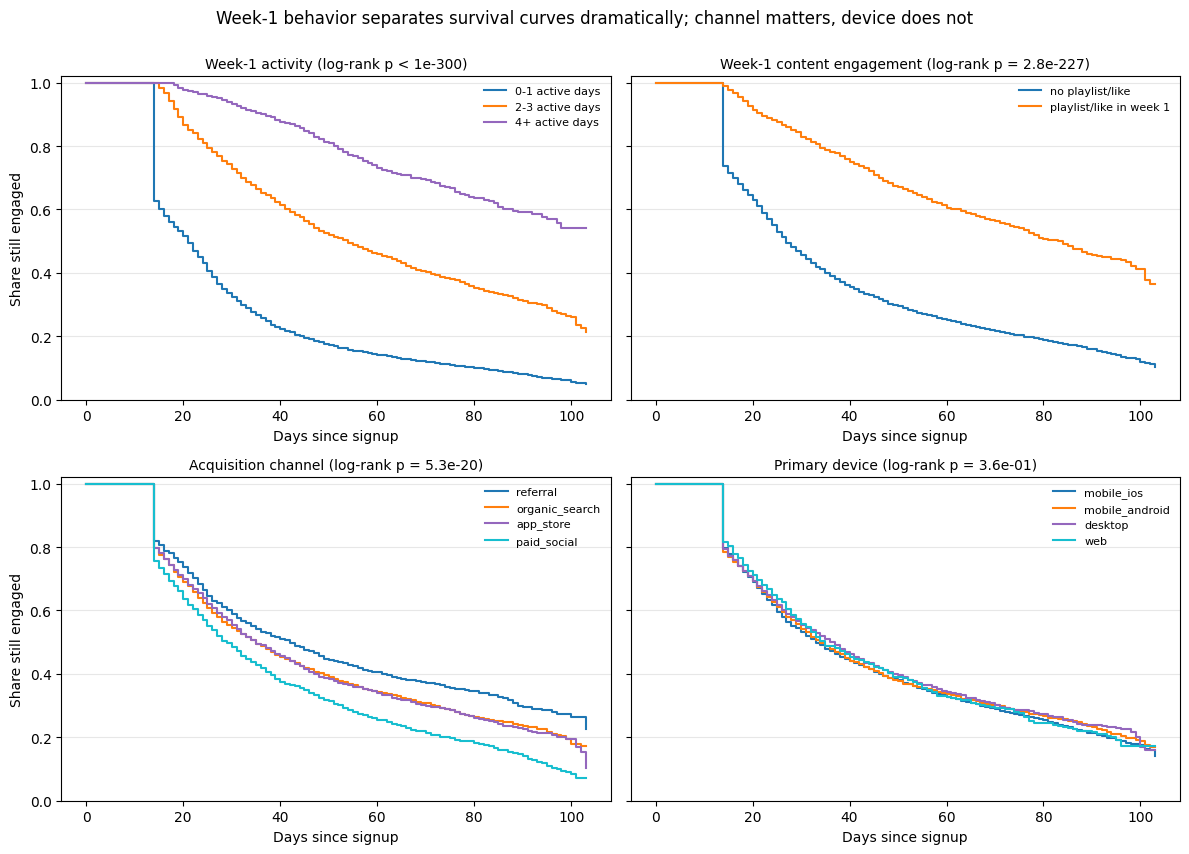

,segmentation,groups,chi2,df,p_value,significant
0,activity_w1,3,3005.7123,2,0.0000,True
1,engagement_w1,2,1035.8959,1,0.0000,True
2,acquisition_channel,7,103.2509,6,0.0000,True
3,device,5,4.3176,4,0.3647,False


In [4]:
survival["activity_w1"] = pd.cut(
    survival["active_days_w1"], [-1, 1, 3, 100],
    labels=["0-1 active days", "2-3 active days", "4+ active days"]
).astype(str)
survival["engagement_w1"] = np.where(
    survival["playlist_or_like_w1"] == 1, "playlist/like in week 1", "no playlist/like"
)

SEGMENTATIONS = [
    ("activity_w1", "Week-1 activity", None),
    ("engagement_w1", "Week-1 content engagement", None),
    ("acquisition_channel", "Acquisition channel",
     ["referral", "organic_search", "app_store", "paid_social"]),
    ("device", "Primary device",
     ["mobile_ios", "mobile_android", "desktop", "web"]),
]

logrank_rows = []
fig, axes = plt.subplots(2, 2, figsize=(12, 8.5), sharey=True)
for ax, (col, title, keep) in zip(axes.ravel(), SEGMENTATIONS):
    curves = km_by_segment(survival, col)
    shown = keep if keep else sorted(curves)
    for color, name in zip(SEGMENT_COLORS, shown):
        curves[name].plot_survival_function(ax=ax, color=color, ci_show=False)
    result = logrank_by_segment(survival, col)
    logrank_rows.append({
        "segmentation": col, "groups": result.n_groups,
        "chi2": result.test_statistic, "df": result.degrees_of_freedom,
        "p_value": result.p_value, "significant": result.significant,
    })
    p_text = "p < 1e-300" if result.p_value == 0 else f"p = {result.p_value:.1e}"
    ax.set_title(f"{title} (log-rank {p_text})", fontsize=10)
    ax.set_xlabel("Days since signup")
    ax.set_ylim(0, 1.02)
    ax.legend(frameon=False, fontsize=8)
    ax.grid(axis="y", alpha=0.3)
axes[0, 0].set_ylabel("Share still engaged")
axes[1, 0].set_ylabel("Share still engaged")
fig.suptitle("Week-1 behavior separates survival curves dramatically; "
             "channel matters, device does not", y=1.0, fontsize=12)
plt.tight_layout()
plt.show()

pd.DataFrame(logrank_rows).round(4)

In [5]:
channel_curves = km_by_segment(survival, "acquisition_channel")
activity_curves = km_by_segment(survival, "activity_w1")
print("Median days to churn by week-1 activity:")
for name in ["0-1 active days", "2-3 active days", "4+ active days"]:
    m = median_survival_summary(activity_curves[name])["median"]
    print(f"  {name}: {'not reached in 103d' if np.isinf(m) else f'{m:.0f} days'}")
print("\nReferral vs paid social over time (share still engaged):")
for t in (30, 60):
    print(f"  day {t}: referral {channel_curves['referral'].predict(t):.1%} "
          f"vs paid_social {channel_curves['paid_social'].predict(t):.1%}")

Median days to churn by week-1 activity:
  0-1 active days: 21 days
  2-3 active days: 54 days
  4+ active days: not reached in 103d

Referral vs paid social over time (share still engaged):
  day 30: referral 58.9% vs paid_social 48.6%
  day 60: referral 40.5% vs paid_social 25.5%


Time-axis findings, connected back to the earlier notebooks:

- **Week-1 activity is destiny** (log-rank χ² = 3,006): users with 0–1 active days in week 1 reach median churn at **day 21**; 2–3 days stretches it to **day 54**; 4+ days never crosses 50% inside the 103-day window. This is notebook 03's "usage habit dominates" finding, now with a clock on it.
- **Content engagement halves early risk over the whole horizon** (χ² = 1,036) — the playlist/liked-song gap from notebook 03 is not an early blip; the curves keep diverging.
- **The referral vs paid-social gap persists and widens**: 58.9% vs 48.6% still engaged at day 30, 40.5% vs 25.5% at day 60. Notebook 04 ranked referral the quality channel at a point in time; the survival view shows the quality difference compounds.
- **Device curves are statistically indistinguishable** (log-rank p = 0.37) — an honest null: device mattered for conversion economics (notebook 03), but it does not shape churn timing.

## 5. Cox Proportional-Hazards: Risk Factors with the Clock Running

Hazard ratios on the leakage-safe landmark covariates (numerics standardized — HRs read "per one standard deviation"), fit on 80% of users, evaluated on the held-out 20%.

In [6]:
survival["log_listen_events_w1"] = np.log1p(survival["listen_events_w1"])
survival["engaged_w1"] = np.where(survival["playlist_or_like_w1"] == 1, "yes", "no")

NUMERIC_COVARIATES = ["active_days_w1", "log_listen_events_w1", "skip_rate_w1"]
CATEGORICAL_COVARIATES = ["engaged_w1", "acquisition_channel", "device"]

train, test = train_test_split(survival, test_size=0.2, random_state=RANDOM_SEED,
                               stratify=survival["churn_event"])
design_train, numeric_stats = build_cox_design(
    train, NUMERIC_COVARIATES, CATEGORICAL_COVARIATES)
design_test, _ = build_cox_design(
    test, NUMERIC_COVARIATES, CATEGORICAL_COVARIATES, numeric_stats=numeric_stats)

cox = fit_cox(design_train)
hr_table = hazard_ratio_table(cox)
c_index = concordance_on_holdout(cox, design_test)
print(f"Held-out C-index ({len(test):,} users): {c_index:.3f}")
hr_table.round(3)

Held-out C-index (1,952 users): 0.759


,covariate,hazard_ratio,ci_low,ci_high,p_value
0,active_days_w1,0.732,0.652,0.822,0.000
1,log_listen_events_w1,0.539,0.482,0.603,0.000
2,skip_rate_w1,1.039,1.012,1.066,0.004
3,engaged_w1_yes,0.895,0.819,0.976,0.013
4,acquisition_channel_email_campaign,0.898,0.776,1.039,0.149
5,acquisition_channel_influencer,0.948,0.851,1.055,0.325
6,acquisition_channel_organic_search,0.997,0.924,1.076,0.947
7,acquisition_channel_paid_social,1.126,1.040,1.219,0.003
8,acquisition_channel_referral,0.866,0.789,0.951,0.003
9,acquisition_channel_student_partner,0.947,0.851,1.055,0.323


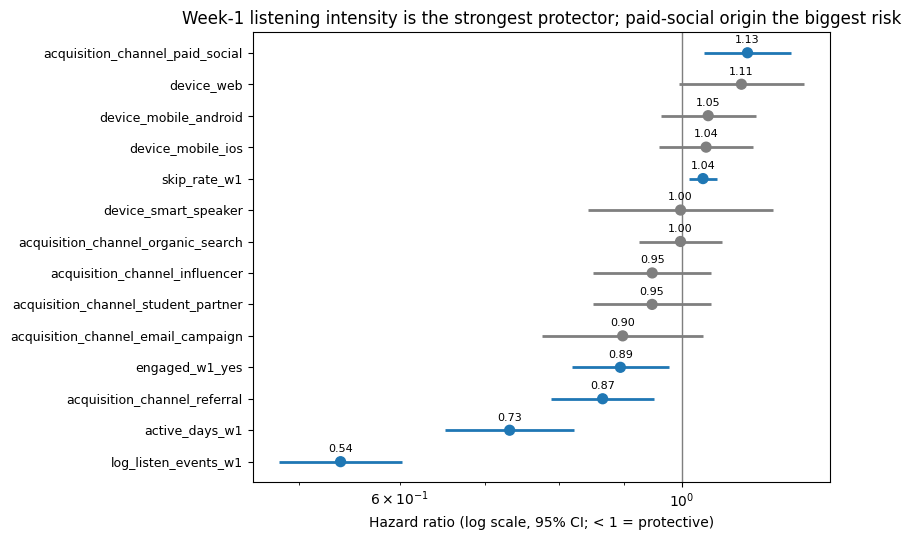

In [7]:
plot_hr = hr_table.sort_values("hazard_ratio")
fig, ax = plt.subplots(figsize=(8.5, 5.5))
y = np.arange(len(plot_hr))
ax.axvline(1.0, color=NEUTRAL_COLOR, linewidth=1)
significant = (plot_hr["ci_low"] > 1) | (plot_hr["ci_high"] < 1)
colors = np.where(significant, SEGMENT_COLORS[0], NEUTRAL_COLOR)
ax.hlines(y, plot_hr["ci_low"].to_numpy(), plot_hr["ci_high"].to_numpy(),
          color=colors, linewidth=2)
ax.scatter(plot_hr["hazard_ratio"].to_numpy(), y, color=colors, s=50, zorder=3)
for yi, (_, row) in zip(y, plot_hr.iterrows()):
    ax.annotate(f"{row['hazard_ratio']:.2f}", xy=(row["hazard_ratio"], yi),
                xytext=(0, 7), textcoords="offset points", ha="center", fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels(plot_hr["covariate"], fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("Hazard ratio (log scale, 95% CI; < 1 = protective)")
ax.set_title("Week-1 listening intensity is the strongest protector; "
             "paid-social origin the biggest risk")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Reading the forest plot (gray = CI crosses 1): one standard deviation more week-1 listening cuts the churn hazard by ~46% (HR 0.54); an extra SD of active days cuts it another ~27% (HR 0.73). Skip rate is a mild accelerant (HR 1.04 per SD). Net of behavior, **paid-social users still carry ~13% higher hazard (HR 1.13) and referral users ~13% lower (HR 0.87)** — the channel effect is not just a behavior-mix artifact. Devices: all CIs cross 1, matching the log-rank null.

## 6. Proportional-Hazards Diagnostics — and What To Do About Violations

Cox assumes each covariate's effect is constant over time. The Schoenfeld-residual test below says three covariates violate that. Rather than ignoring it, the follow-up splits the timeline at day 30 and refits, showing *how* the effects drift.

In [8]:
ph = check_proportional_hazards(cox, design_train)
print(f"{int(ph['violated'].sum())} of {len(ph)} covariates violate PH at alpha=0.05:")
ph[ph["violated"]].round(4)

3 of 14 covariates violate PH at alpha=0.05:


,covariate,test_statistic,p_value,violated
10,device_web,7.8531,0.0051,True
12,log_listen_events_w1,60.4682,0.0000,True
13,skip_rate_w1,5.5839,0.0181,True


   window                       covariate  hazard_ratio  ci_low  ci_high
days 0-30            log_listen_events_w1         0.537   0.462    0.624
days 0-30                  active_days_w1         0.525   0.442    0.623
days 0-30 acquisition_channel_paid_social         1.053   0.964    1.151
days 0-30    acquisition_channel_referral         0.936   0.844    1.037
  day 30+            log_listen_events_w1         0.820   0.720    0.934
  day 30+                  active_days_w1         0.701   0.614    0.801
  day 30+ acquisition_channel_paid_social         1.232   1.095    1.386
  day 30+    acquisition_channel_referral         0.768   0.668    0.882


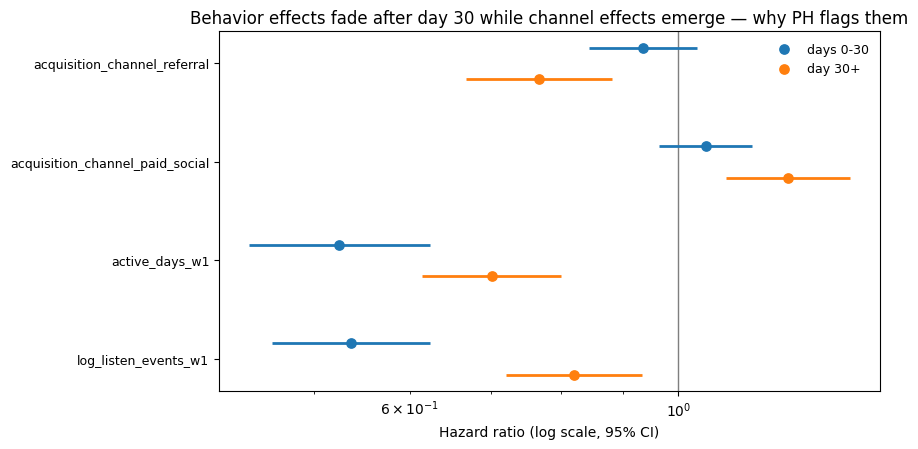

In [9]:
SPLIT_DAY = 30
early = survival.copy()
early["churn_event"] = ((survival["churn_event"] == 1)
                        & (survival["duration_days"] <= SPLIT_DAY)).astype(int)
early["duration_days"] = survival["duration_days"].clip(upper=SPLIT_DAY)
late = survival[survival["duration_days"] > SPLIT_DAY].copy()
late["duration_days"] = late["duration_days"] - SPLIT_DAY

FOCUS = ["log_listen_events_w1", "active_days_w1",
         "acquisition_channel_paid_social", "acquisition_channel_referral"]
window_rows = []
for window, frame in [("days 0-30", early), (f"day 30+", late)]:
    design, _ = build_cox_design(frame, NUMERIC_COVARIATES, CATEGORICAL_COVARIATES)
    window_hr = hazard_ratio_table(fit_cox(design)).set_index("covariate")
    for covariate in FOCUS:
        row = window_hr.loc[covariate]
        window_rows.append({"window": window, "covariate": covariate,
                            "hazard_ratio": row["hazard_ratio"],
                            "ci_low": row["ci_low"], "ci_high": row["ci_high"]})
window_df = pd.DataFrame(window_rows)
print(window_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.6))
y = np.arange(len(FOCUS))
offsets = {"days 0-30": 0.16, "day 30+": -0.16}
colors = {"days 0-30": SEGMENT_COLORS[0], "day 30+": SEGMENT_COLORS[1]}
ax.axvline(1.0, color=NEUTRAL_COLOR, linewidth=1)
for window in offsets:
    sub = window_df[window_df["window"] == window].set_index("covariate").loc[FOCUS]
    ax.hlines(y + offsets[window], sub["ci_low"].to_numpy(), sub["ci_high"].to_numpy(),
              color=colors[window], linewidth=2)
    ax.scatter(sub["hazard_ratio"].to_numpy(), y + offsets[window],
               color=colors[window], s=45, zorder=3, label=window)
ax.set_yticks(y)
ax.set_yticklabels(FOCUS, fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("Hazard ratio (log scale, 95% CI)")
ax.set_title("Behavior effects fade after day 30 while channel effects emerge — "
             "why PH flags them")
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

The violations are informative, not fatal:

- **Week-1 listening intensity protects hard early, then fades** (HR 0.54 in days 0–30 → 0.82 after day 30): an old onboarding signal cannot keep predicting forever. This is the χ² = 60 violation.
- **Channel effects run the other way — they *emerge* late**: paid social 1.05 (n.s.) early → **1.23** late; referral 0.94 (n.s.) early → **0.77** late. Early churn is behavior-driven regardless of origin; past day 30, acquisition quality shows.
- Robustness: stratifying the baseline hazard by week-1 listening tier (the standard remedy) leaves the channel and engagement HRs essentially unchanged (paid social 1.13, referral 0.87), so the pooled model's conclusions stand — its HRs for the flagged covariates should simply be read as **time-averaged effects**.

## 7. What Cox Adds Over the Binary Classifier

Notebook 05's logistic regression scores *established* users at a snapshot (ROC-AUC 0.788 on 30-day behavioral features). The Cox model ranks *brand-new* users from week-1 signals only, and holds a **C-index of 0.759** on held-out users — nearly the same discrimination, available from day 7 instead of day 30+, and with a full time profile instead of one probability:

- The classifier answers "who is at risk *now*" — right tool for monthly outreach targeting.
- Cox answers "who will disengage *and when*" — right tool for timing onboarding interventions and lifecycle messaging, and it prices censoring correctly instead of discarding incomplete windows.

## 8. Intervention Windows: When to Act

The event is dated when 14 days of silence *complete* — but action must come earlier. The actionable quantity is the **disengagement onset**: the last day of activity before the fatal silence (duration − 14).

Among the 6,930 churn events:
  onset on signup day itself: 28.7%
  onset within 3 days:        36.0%
  onset within 7 days:        45.3%
  median onset day:           9


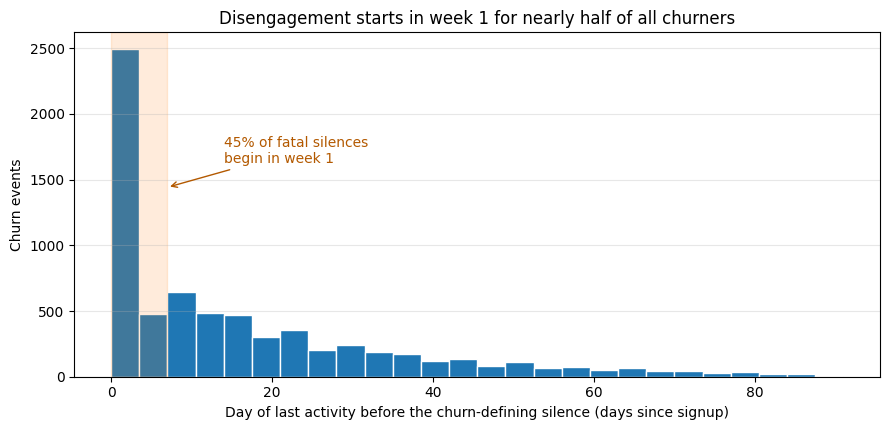

In [10]:
onset = survival.loc[survival["churn_event"] == 1, "duration_days"] - 14
onset_share_0 = float((onset == 0).mean())
onset_share_3 = float((onset <= 3).mean())
onset_share_7 = float((onset <= 7).mean())
print(f"Among the {len(onset):,} churn events:")
print(f"  onset on signup day itself: {onset_share_0:.1%}")
print(f"  onset within 3 days:        {onset_share_3:.1%}")
print(f"  onset within 7 days:        {onset_share_7:.1%}")
print(f"  median onset day:           {onset.median():.0f}")

fig, ax = plt.subplots(figsize=(9, 4.4))
bins = np.arange(0, 92, 3.5)
ax.hist(onset.to_numpy(), bins=bins, color=SEGMENT_COLORS[0], edgecolor="white")
ax.axvspan(0, 7, color=SEGMENT_COLORS[1], alpha=0.15)
ax.annotate(f"{onset_share_7:.0%} of fatal silences\nbegin in week 1",
            xy=(7, ax.get_ylim()[1] * 0.55), xytext=(14, ax.get_ylim()[1] * 0.62),
            fontsize=10, color="#b35900",
            arrowprops={"arrowstyle": "->", "color": "#b35900"})
ax.set_xlabel("Day of last activity before the churn-defining silence (days since signup)")
ax.set_ylabel("Churn events")
ax.set_title("Disengagement starts in week 1 for nearly half of all churners")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**The intervention calendar this implies:**

1. **Days 0–3 — onboarding is the whole game for a third of churners.** 28.7% of fatal silences begin on signup day itself (the user signs up, listens once or never, and never returns); 36% begin within 3 days. Content-discovery nudges (the notebook-06 experiment surface) belong here, not at day 14.
2. **Day 8–13 — the last-chance window.** A user silent since day ≤ 7 has not yet *completed* churn; a re-engagement trigger at ~7 days of silence fires before the state becomes permanent by definition.
3. **Weeks 3–5 — the established-user watch.** Median onset is day 9, but the median *completed* churn is day 35; users who survive week 1 disengage gradually across weeks 3–5 — lifecycle messaging and the paid-social quality problem (HR 1.23 after day 30) live in this window.

## 9. Key Findings

Cohort: 9,759 users who signed up inside the event-log window; churn = first 14-day listening silence; 71.0% experienced it within up to 103 days of follow-up, 29.0% censored.

- **Half of a signup cohort disengages within 35 days** (median survival 35 days, 95% CI [33, 35]); 20.4% are gone at day 14, 66.7% by day 60. Retention is a first-five-weeks problem.
- **Week-1 behavior sets the clock** (log-rank χ² = 3,006): median churn at day 21 for users with ≤ 1 active day in week 1, day 54 with 2–3 days, not reached in 103 days with 4+. One SD more week-1 listening cuts the hazard 46% (HR 0.54).
- **The referral vs paid-social quality gap widens over time** — 10pp of engagement at day 30, 15pp at day 60 — and survives behavioral controls (Cox HR 0.87 vs 1.13, diverging to 0.77 vs 1.23 after day 30). Notebook 04's channel ranking is not an early-funnel artifact.
- **Device does not shape churn timing** (log-rank p = 0.37; all Cox CIs cross 1) — an honest null that narrows where retention levers can live.
- **PH violations were diagnosed and explained, not ignored:** week-1 behavior effects fade after day 30 (HR 0.54 → 0.82) while channel effects emerge late; stratified refits leave conclusions unchanged, so pooled HRs read as time-averaged effects.
- **Cox from week-1 signals holds a held-out C-index of 0.759** — near the binary classifier's 0.788 discrimination, but available three weeks earlier per user and with a full time-to-churn profile: the classifier targets outreach, Cox times it.
- **45% of fatal silences begin in week 1** (28.7% on signup day itself; median onset day 9) → onboarding nudges belong in days 0–3, a silence-triggered re-engagement message at ~7 quiet days, lifecycle attention in weeks 3–5.

**Caveats.** Simulated data; the cohort covers at most 103 days of follow-up, so long-run behavior past ~3 months is unobserved. Week-1 covariates are the price of leakage safety: richer time-varying covariates (rolling engagement) would need a start-stop Cox formulation. The 14-day-gap definition treats reactivated users as churned at their first silence — appropriate for intervention timing, but not a lifetime-value measure.